<img src="https://github.com/gefero/factor_data_SICSS_Baires_2026/blob/main/imgs/logo_final_conjunto.png?raw=true" width="80%">


# Summer Institute in Computational Social Sciences - Buenos Aires 2026
# Taller: Procesamiento de Lenguaje Natural y polarización
# Acuerdo entre anotadores

### Profesor: Germán Rosati



La notebook anterior (`03_SICSS_Baires_LLMs_y_Anotación.ipynb`) mostró cómo pedirle a un LLM que
anote discurso de odio con el mismo esquema que usamos con codificadores humanos. Antes de comparar
a un modelo contra personas, conviene preguntarse algo más básico: **¿cuánto acuerdan las personas
entre sí?** Si dos humanos ya discrepan bastante en una tarea, exigirle a un LLM un acuerdo perfecto
es pedirle algo que ni los propios humanos logran.

Para eso usamos `data/sicss-anotacion-unificado.json`: 10 codificadores anotaron, cada uno por su
cuenta, el mismo conjunto de 74 tweets con el esquema `HATEFUL` / `OFFENSIVE` / `CALLS` + 8
categorías temáticas (`WOMEN`, `LGBTI`, `RACISM`, `CLASS`, `POLITICS`, `DISABLED`, `APPEARANCE`,
`CRIMINAL`) — el mismo `CommentLabel` de la notebook de Anotación.

En esta notebook vamos a:

1. Calcular el **acuerdo observado**, el **kappa de Cohen** (par a par), el **kappa de Fleiss** y el
   **alfa de Krippendorff** (multi-anotador) para cada etiqueta.
2. Mostrar la **paradoja de kappa**: por qué una etiqueta rara puede tener acuerdo altísimo y kappa
   bajo, sin que eso signifique que los anotadores no se entienden.
3. Ver **quién acuerda con quién**, y si algún codificador se comporta distinto al resto.
4. Cuantificar el **sesgo de severidad**: distintos anotadores usan un umbral distinto para lo que
   cuenta como odio u ofensa.
5. Mirar **qué tweets generan más desacuerdo**, y por qué.
6. Cerrar con lo que esto implica para evaluar a un LLM anotador.


# Los datos


In [ ]:
## Ejecutar para clonar el repo con los datos (en Colab)
!git clone https://github.com/gefero/factor_data_SICSS_Baires_2026.git

Cloning into 'factor_data_SICSS_Baires_2026'...


remote: Enumerating objects: 235, done.
remote: Counting objects: 100% (220/220), done.


remote: Compressing objects: 100% (156/156), done.


remote: Total 235 (delta 131), reused 150 (delta 63), pack-reused 15 (from 1)
Receiving objects: 100% (235/235), 147.51 MiB | 26.00 MiB/s, done.
Resolving deltas: 100% (133/133), done.


Updating files: 100% (34/34), done.


In [ ]:
import itertools
import json
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import aggregate_raters, fleiss_kappa

warnings.filterwarnings("ignore")  # cohen_kappa_score tira warnings cuando un par tiene una sola clase
pd.set_option("display.width", 120)

In [ ]:
# Soporta correr tanto desde el repo recién clonado (Colab) como localmente
data_path = "./factor_data_SICSS_Baires_2026/data/sicss-anotacion-unificado.json"
if not os.path.exists(data_path):
    data_path = "../../data/sicss-anotacion-unificado.json"

df = pd.DataFrame(json.load(open(data_path, encoding="utf-8")))
df.head()

,id,tweet_id,article_id,text,annotator,HATEFUL,OFFENSIVE,CALLS,WOMEN,LGBTI,RACISM,CLASS,POLITICS,DISABLED,APPEARANCE,CRIMINAL,coder_id
0,357080,1308796793237495809,1308766339306315777,@usuario Todos los políticamente correctos se ...,danae_alfonsina,True,False,False,False,False,True,False,False,False,False,False,danae_alfonsina
1,385826,1305048368939520000,1304779775219765248,@usuario Estamos en el 2020 y siguen publicand...,danae_alfonsina,False,False,False,False,False,False,False,False,False,False,False,danae_alfonsina
2,337469,1290356305702653964,1290354863914835976,@usuario Jajaja que hija de puta,danae_alfonsina,False,True,False,False,False,False,False,False,False,False,False,danae_alfonsina
3,352094,1264375820652630018,1264374365367525376,@usuario 4 años de gobierno y no pudieron con ...,danae_alfonsina,False,False,False,False,False,False,False,False,False,False,False,danae_alfonsina
4,378931,1298275195984248832,1298229400165638144,"@usuario Los Chinos en son al mundo, lo que so...",danae_alfonsina,True,False,False,False,False,True,False,False,False,False,False,danae_alfonsina


El campo clave para este análisis es `coder_id`, no `annotator`: tres de los diez archivos
originales tenían `annotator == "anonymous"` (tres personas distintas que no pusieron su nombre), y
`unify_anotaciones.py` ya los desambiguó como `anonymous_1`, `anonymous_2`, `anonymous_3` al unificar.
Si trabajáramos con `annotator` a secas, esas tres identidades se mezclarían en una sola y cualquier
métrica de acuerdo por codificador quedaría mal calculada.

Verificamos que el diseño sea lo que esperamos: **10 codificadores, 74 tweets cada uno, sin
faltantes** (diseño "cruzado completo"). Eso es lo que habilita calcular Fleiss/Krippendorff, que
necesitan que todos los ítems tengan el mismo número de anotaciones.

In [ ]:
LABELS = ["HATEFUL", "OFFENSIVE", "CALLS", "WOMEN", "LGBTI", "RACISM",
          "CLASS", "POLITICS", "DISABLED", "APPEARANCE", "CRIMINAL"]

coders = sorted(df["coder_id"].unique())
items = sorted(df["id"].unique())

print(f"{len(coders)} codificadores: {coders}")
print(f"{len(items)} tweets anotados")
print(f"{len(df)} registros = {len(coders)} x {len(items)}")

conteo = df.groupby("coder_id").size()
assert (conteo == len(items)).all(), "hay codificadores con menos de 74 anotaciones"
print("Diseño cruzado completo: OK (cada codificador anotó los 74 tweets, sin faltantes)")

10 codificadores: ['BarEstevez', 'Julieta', 'Mariano', 'Valentina', 'agustinnielsen', 'anonymous_1', 'anonymous_2', 'anonymous_3', 'danae_alfonsina', 'gefero']
74 tweets anotados
740 registros = 10 x 74
Diseño cruzado completo: OK (cada codificador anotó los 74 tweets, sin faltantes)


# Métricas de acuerdo: qué vamos a calcular

- **Acuerdo observado ($p_o$)**: proporción de pares de codificadores que coinciden en un ítem,
  promediada sobre todos los pares e ítems. Es intuitivo, pero no descuenta el acuerdo que pasaría
  igual por azar.
- **Kappa de Cohen** (`sklearn.metrics.cohen_kappa_score`): $(p_o - p_e) / (1 - p_e)$, calculado
  **par a par** (Cohen es para dos anotadores). Lo promediamos sobre los 45 pares posibles de 10
  codificadores.
- **Kappa de Fleiss** (`statsmodels`): la generalización de Cohen a **más de dos** anotadores, usando
  a los 10 codificadores en simultáneo en vez de promediar pares.
- **Alfa de Krippendorff**: otra generalización multi-anotador, con una forma distinta de calcular el
  desacuerdo esperado por azar. La implementamos a mano (es corta para datos sin faltantes) para ver
  la fórmula en vez de tratarla como caja negra.
- **PABAK** (*Prevalence-Adjusted Bias-Adjusted Kappa* $= 2p_o - 1$): un diagnóstico, no una medida de
  acuerdo "mejor". Sirve para separar cuánto de un kappa bajo se explica por prevalencia extrema.

Con un diseño cruzado completo y etiquetas binarias, Fleiss y Krippendorff deberían dar valores muy
parecidos entre sí — es un buen chequeo de que no hay un error de implementación.

In [ ]:
def pivot(label):
    """Matriz items x codificadores (0/1) para una etiqueta, en orden fijo de coders/items."""
    return (
        df.pivot(index="id", columns="coder_id", values=label)
        .loc[items, coders]
        .astype(int)
    )


def krippendorff_alpha_nominal(mat: pd.DataFrame) -> float:
    """Alfa de Krippendorff (nivel nominal) para una matriz completa items x codificadores.

    Válido porque no hay valores faltantes: todos los ítems tienen la misma cantidad de
    anotaciones (m = 10). Se implementa siguiendo la definición directa de Krippendorff:
    alpha = 1 - Do/De, con Do el desacuerdo observado por pares dentro de cada ítem y De el
    desacuerdo esperado si las etiquetas se repartieran al azar según su frecuencia global.
    """
    vals = mat.values
    n_items, m = vals.shape
    categorias = np.unique(vals)

    Do = 0.0
    total_pares = 0
    total_por_categoria = {c: 0 for c in categorias}
    for i in range(n_items):
        fila = vals[i]
        conteos = {c: int(np.sum(fila == c)) for c in categorias}
        for c in categorias:
            total_por_categoria[c] += conteos[c]
        pares_item = m * (m - 1)
        pares_de_acuerdo = sum(v * (v - 1) for v in conteos.values())
        Do += pares_item - pares_de_acuerdo
        total_pares += pares_item
    Do /= total_pares

    N = n_items * m
    De = 1 - sum(n * (n - 1) for n in total_por_categoria.values()) / (N * (N - 1))

    return 1 - Do / De


def metricas_de_acuerdo(label: str) -> dict:
    mat = pivot(label)
    vals = mat.values
    n_items, n_coders = vals.shape

    po_list, kappas = [], []
    for i, j in itertools.combinations(range(n_coders), 2):
        a, b = vals[:, i], vals[:, j]
        po_list.append(np.mean(a == b))
        kappas.append(cohen_kappa_score(a, b))

    agg, _ = aggregate_raters(vals)

    prevalencia_por_coder = vals.mean(axis=0)

    return {
        "label": label,
        "prevalencia": vals.mean(),
        "prev_min": prevalencia_por_coder.min(),
        "prev_max": prevalencia_por_coder.max(),
        "po": np.mean(po_list),
        "cohen_kappa": np.nanmean(kappas),
        "fleiss_kappa": fleiss_kappa(agg),
        "alpha": krippendorff_alpha_nominal(mat),
        "pabak": 2 * np.mean(po_list) - 1,
    }

# Tabla maestra

Una fila por etiqueta, ordenadas de mayor a menor kappa de Fleiss.

In [ ]:
tabla = pd.DataFrame([metricas_de_acuerdo(l) for l in LABELS]).set_index("label")
tabla = tabla.sort_values("fleiss_kappa", ascending=False)
tabla.round(3)

,prevalencia,prev_min,prev_max,po,cohen_kappa,fleiss_kappa,alpha,pabak
label,,,,,,,,
LGBTI,0.041,0.041,0.041,1.000,1.000,1.000,1.000,1.000
RACISM,0.115,0.081,0.176,0.950,0.758,0.753,0.754,0.900
CRIMINAL,0.064,0.014,0.095,0.965,0.657,0.710,0.710,0.931
HATEFUL,0.442,0.284,0.527,0.817,0.629,0.629,0.630,0.634
WOMEN,0.061,0.014,0.095,0.953,0.573,0.587,0.588,0.906
CLASS,0.086,0.014,0.149,0.933,0.553,0.574,0.575,0.865
POLITICS,0.109,0.027,0.176,0.911,0.533,0.546,0.546,0.823
CALLS,0.046,0.014,0.068,0.950,0.393,0.431,0.432,0.900
APPEARANCE,0.030,0.000,0.081,0.966,0.383,0.407,0.407,0.932


**Primer chequeo de sanidad**: `fleiss_kappa` y `alpha` son casi idénticos fila por fila, como se
esperaba para datos binarios sin faltantes — si divergieran fuerte, habría un error en alguna de las
dos implementaciones.

**Lectura rápida**: `HATEFUL` (kappa de Fleiss ≈ 0,63, "acuerdo sustancial" en la escala de Landis y
Koch) es, con diferencia, la etiqueta más confiable. `OFFENSIVE` (≈ 0,22, "acuerdo leve") es mucho más
ruidosa a pesar de tener un acuerdo observado del 63% — nada trivial, como vemos abajo. Las 8
categorías temáticas son en su mayoría eventos raros (prevalencia entre 1,5% y 11,5%), y ahí conviene
mirar con cuidado antes de leer el kappa literalmente.

# La paradoja de kappa

Miremos dos filas de la tabla que parecen contradictorias: `DISABLED` y `LGBTI`. Ambas son categorías
raras (prevalencia 1,5% y 4,1%), y ambas tienen acuerdo observado altísimo. Pero una tiene kappa casi
nulo y la otra kappa perfecto.

In [ ]:
tabla.loc[["LGBTI", "DISABLED"], ["prevalencia", "po", "cohen_kappa", "fleiss_kappa", "pabak"]].round(3)

,prevalencia,po,cohen_kappa,fleiss_kappa,pabak
label,,,,,
LGBTI,0.041,1.000,1.000,1.00,1.000
DISABLED,0.015,0.976,0.112,0.19,0.953


In [ ]:
# LGBTI: ¿cuántos tweets tienen al menos un voto?
votos_lgbti = pivot("LGBTI").sum(axis=1)
print("Tweets con algún voto LGBTI:", (votos_lgbti > 0).sum(), "de", len(items))
print("Votos por tweet (de 10 codificadores):")
print(votos_lgbti[votos_lgbti > 0])

Tweets con algún voto LGBTI: 3 de 74
Votos por tweet (de 10 codificadores):
id
373822    10
396663    10
405360    10
dtype: int64


`LGBTI` tiene kappa = 1,0 porque solo 3 de los 74 tweets tocan el tema, y en esos 3 los **10**
codificadores coinciden exactamente (10/10 votos). Es acuerdo real y perfecto sobre una categoría poco
frecuente pero inequívoca.

`DISABLED` también es rara (11/740 anotaciones), pero ahí los pocos votos positivos **no** se
concentran limpiamente en los mismos tweets: distintos codificadores marcan `DISABLED` en distintos
ítems, así que el acuerdo observado (97,6%) es alto simplemente porque casi todo el mundo dice "No" —
la coincidencia en los pocos "Sí" es baja. Ahí es donde aparece la **paradoja de kappa**: cuando una
categoría es muy rara, el acuerdo esperado por azar ($p_e$) también es altísimo (dos anotadores que
tiraran una moneda muy cargada hacia "No" igual coincidirían casi siempre), así que el numerador
$(p_o - p_e)$ se achica aunque $p_o$ sea alto. El kappa termina castigando la prevalencia extrema, no
necesariamente la falta de entendimiento entre anotadores.

El PABAK (que ignora la prevalencia y solo reescala $p_o$) es el diagnóstico: `DISABLED` tiene PABAK
≈ 0,95 pero kappa ≈ 0,19 — la brecha entre ambos números *es* la señal de que ahí el kappa está siendo
demasiado pesimista. Conviene reportar los dos, no reemplazar uno por el otro: el kappa sigue siendo
la medida correcta para "cuánto le agrega el acuerdo humano a adivinar al azar", el PABAK solo ayuda a
interpretarlo cuando la prevalencia es extrema.

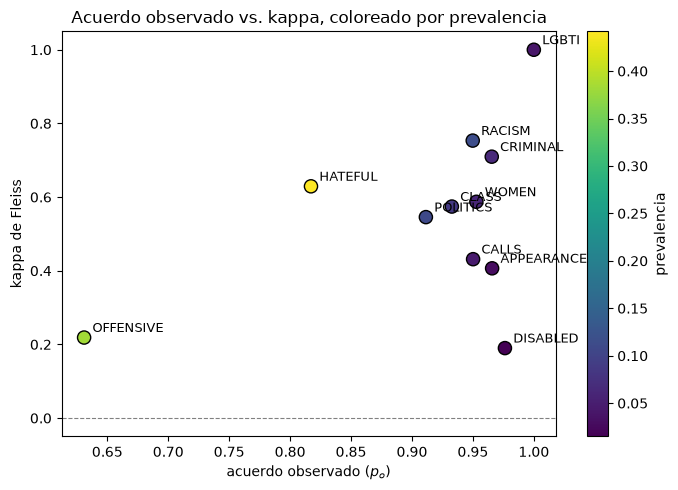

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(tabla["po"], tabla["fleiss_kappa"], c=tabla["prevalencia"], cmap="viridis", s=90, edgecolor="k")
for label, row in tabla.iterrows():
    ax.annotate(label, (row["po"], row["fleiss_kappa"]), textcoords="offset points", xytext=(6, 4), fontsize=9)
plt.colorbar(sc, label="prevalencia")
ax.set_xlabel("acuerdo observado ($p_o$)")
ax.set_ylabel("kappa de Fleiss")
ax.set_title("Acuerdo observado vs. kappa, coloreado por prevalencia")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

El patrón general: a mayor prevalencia (colores más claros: `HATEFUL`, `OFFENSIVE`), el kappa se
acerca más al acuerdo observado. Las etiquetas de prevalencia baja (colores oscuros) se desparraman
verticalmente para un mismo $p_o$ ≈ 0,95–0,98 — ahí es donde vale la pena mirar el detalle caso por
caso en vez de comparar los kappas entre sí como si fueran la misma escala.

# ¿Quién acuerda con quién?

Hasta acá promediamos los 45 pares de codificadores en un solo número por etiqueta. Pero el promedio
esconde si hay codificadores que se llevan bien entre sí y otros que son sistemáticamente distintos al
resto. Miramos la matriz de kappa par a par para `HATEFUL` y `OFFENSIVE`.

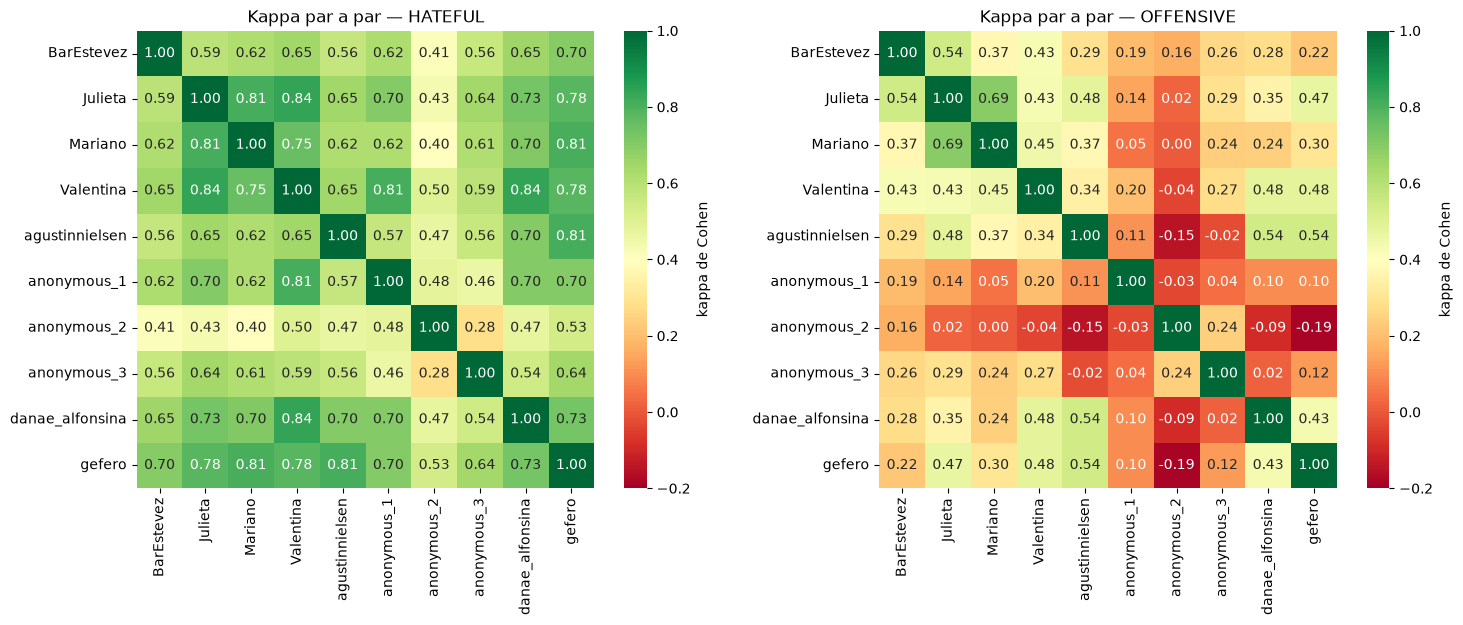

In [ ]:
def matriz_pairwise_kappa(label):
    mat = pivot(label)
    vals = mat.values
    pw = pd.DataFrame(index=coders, columns=coders, dtype=float)
    for i, j in itertools.combinations(range(len(coders)), 2):
        k = cohen_kappa_score(vals[:, i], vals[:, j])
        pw.iloc[i, j] = pw.iloc[j, i] = k
    for i in range(len(coders)):
        pw.iloc[i, i] = 1.0
    return pw


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, label in zip(axes, ["HATEFUL", "OFFENSIVE"]):
    pw = matriz_pairwise_kappa(label)
    sns.heatmap(pw, annot=True, fmt=".2f", cmap="RdYlGn", vmin=-0.2, vmax=1, center=0.4,
                square=True, ax=ax, cbar_kws={"label": "kappa de Cohen"})
    ax.set_title(f"Kappa par a par — {label}")
plt.tight_layout()
plt.show()

Dos cosas saltan a la vista:

- **`anonymous_2` es un outlier claro en ambas etiquetas.** En `HATEFUL` sus kappas contra el resto
  rondan 0,4–0,5, bastante por debajo del resto de la matriz (que en general está en 0,6–0,85). En
  `OFFENSIVE` es todavía más marcado: varios de sus kappas contra otros codificadores son cercanos a
  cero o **negativos** (peor que el azar).
- **El bloque `Julieta` / `Mariano` / `Valentina` / `danae_alfonsina` / `gefero` acuerda fuerte entre
  sí en `HATEFUL`** (varios pares por encima de 0,75-0,84), mientras que en `OFFENSIVE` ningún par
  llega a acuerdo "sustancial": el techo ronda 0,5-0,54, confirmando a nivel de pares lo que ya se veía
  en la tabla maestra — `OFFENSIVE` es una etiqueta genuinamente más subjetiva que `HATEFUL` para
  *todo el mundo*, no solo en promedio.

# Sesgo de severidad por codificador

Una causa típica de bajo acuerdo no es que los codificadores no entiendan la tarea, sino que usan un
**umbral distinto**: alguien más estricto marca "odio" u "ofensivo" con más frecuencia que alguien más
laxo, aunque ambos apliquen el mismo criterio de fondo en cada caso individual. Miramos la prevalencia
de `HATEFUL` y `OFFENSIVE` por codificador.

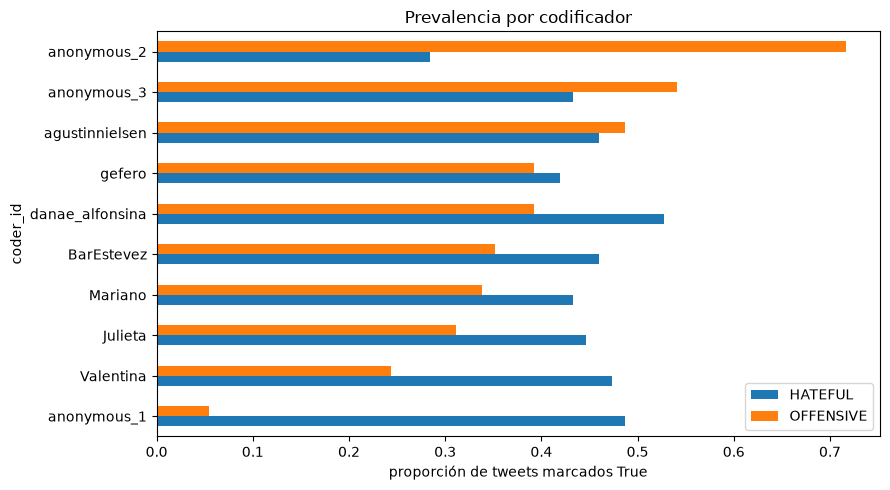

,HATEFUL,OFFENSIVE
coder_id,,
anonymous_1,0.486,0.054
Valentina,0.473,0.243
Julieta,0.446,0.311
Mariano,0.432,0.338
BarEstevez,0.459,0.351
danae_alfonsina,0.527,0.392
gefero,0.419,0.392
agustinnielsen,0.459,0.486
anonymous_3,0.432,0.541


In [ ]:
prevalencia_coder = pd.DataFrame({
    "HATEFUL": pivot("HATEFUL").mean(axis=0),
    "OFFENSIVE": pivot("OFFENSIVE").mean(axis=0),
}).sort_values("OFFENSIVE")

fig, ax = plt.subplots(figsize=(9, 5))
prevalencia_coder.plot.barh(ax=ax)
ax.set_xlabel("proporción de tweets marcados True")
ax.set_title("Prevalencia por codificador")
ax.legend(title=None)
plt.tight_layout()
plt.show()

prevalencia_coder.round(3)

`HATEFUL` es relativamente estable: va de 0,28 (`anonymous_2`) a 0,53 (`danae_alfonsina`), un rango
de ~0,25. `OFFENSIVE` es otra historia: va de **0,054** (`anonymous_1`, casi nunca marca algo como
ofensivo) a **0,716** (`anonymous_2`, lo marca en 7 de cada 10 tweets) — un rango de 0,66, más del
doble que `HATEFUL`. Esa dispersión enorme en el umbral de "qué es ofensivo" es, en gran medida, la
explicación del kappa bajo de `OFFENSIVE`: no es que los codificadores discrepen al azar tweet por
tweet, es que parten de definiciones personales muy distintas de dónde poner la vara.

Para separar "¿este codificador se parece al resto?" de la comparación par a par, calculamos un kappa
**leave-one-out**: cada codificador contra el voto mayoritario de los otros 9.

In [ ]:
def kappa_leave_one_out(label):
    mat = pivot(label)
    out = {}
    for c in coders:
        resto = mat.drop(columns=[c])
        mayoria = (resto.sum(axis=1) > resto.shape[1] / 2).astype(int)
        out[c] = cohen_kappa_score(mat[c].values, mayoria.values)
    return pd.Series(out, name=label)


loo = pd.DataFrame({
    "HATEFUL": kappa_leave_one_out("HATEFUL"),
    "OFFENSIVE": kappa_leave_one_out("OFFENSIVE"),
}).sort_values("OFFENSIVE")
loo.round(3)

,HATEFUL,OFFENSIVE
anonymous_2,0.490,0.024
anonymous_1,0.756,0.191
anonymous_3,0.617,0.240
gefero,0.863,0.411
danae_alfonsina,0.786,0.470
agustinnielsen,0.728,0.481
Mariano,0.753,0.542
Valentina,0.836,0.564
BarEstevez,0.672,0.577
Julieta,0.808,0.685


El ranking confirma la lectura: `anonymous_2` es el codificador más alejado del consenso en las dos
etiquetas (kappa leave-one-out 0,49 en `HATEFUL` y apenas 0,02 en `OFFENSIVE` — prácticamente
independiente de lo que dice el resto del grupo), mientras que `Julieta` y `gefero` son los más
alineados con la mayoría. Esto no dice quién "tiene razón" — no hay una verdad de base independiente
de los propios anotadores — pero sí identifica a los codificadores cuyo criterio conviene revisar o
recalibrar antes de usarlos para entrenar o evaluar un modelo.

# ¿Qué tweets generan más desacuerdo?

Damos vuelta la pregunta: en vez de mirar codificadores, miramos ítems. ¿Cuántos de los 74 tweets
tienen acuerdo unánime en `HATEFUL`, y cómo son los que no?

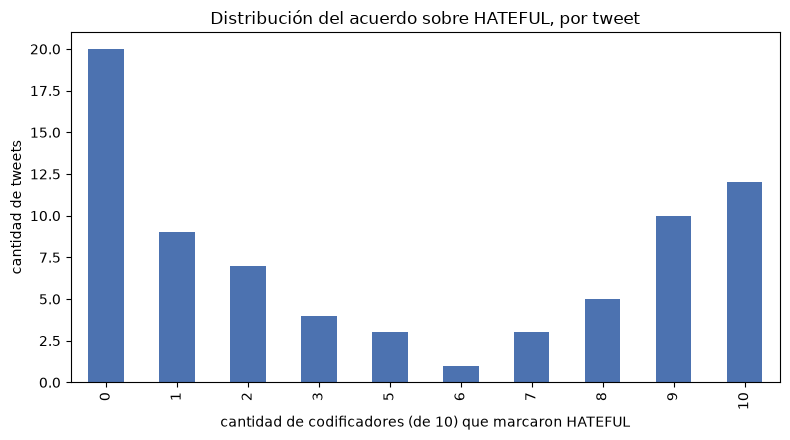

Tweets unánimes: 32 de 74 (43%)


In [ ]:
votos_hateful = pivot("HATEFUL").sum(axis=1)  # cuántos de los 10 codificadores dijeron HATEFUL=True

fig, ax = plt.subplots(figsize=(8, 4.5))
votos_hateful.value_counts().sort_index().plot.bar(ax=ax, color="#4C72B0")
ax.set_xlabel("cantidad de codificadores (de 10) que marcaron HATEFUL")
ax.set_ylabel("cantidad de tweets")
ax.set_title("Distribución del acuerdo sobre HATEFUL, por tweet")
plt.tight_layout()
plt.show()

unanimes = ((votos_hateful == 0) | (votos_hateful == 10)).sum()
print(f"Tweets unánimes: {unanimes} de {len(items)} ({unanimes/len(items):.0%})")

Un poco menos de la mitad de los tweets (32/74) tienen acuerdo unánime — 20 donde nadie marcó odio y
12 donde los 10 codificadores coincidieron en que sí lo había. El resto (42/74) es zona gris real, no
un residuo marginal. Miremos los tweets más disputados: los que quedaron más cerca de un empate 5-5.

In [ ]:
disputa = (votos_hateful - 5).abs().sort_values()
mas_disputados = df[df["id"].isin(disputa.index[:8])][["id", "text"]].drop_duplicates("id").set_index("id")
mas_disputados["votos_HATEFUL_de_10"] = votos_hateful
mas_disputados.sort_values("votos_HATEFUL_de_10")

,text,votos_HATEFUL_de_10
id,,
329016,@usuario @usuario no seas boludo. Que rindan l...,3
373983,"@usuario La enfermita está mejor que yo,y no s...",5
358669,@usuario Resentimiento e hipocresía... No le c...,5
378055,@usuario No me ofendería si en plena sesión se...,5
353321,@usuario Lástima la cara,6
369507,@usuario Falso. Administraron bien CABA y uste...,7
352857,@usuario Y si estaban de motin....,7
374959,"@usuario No sé olvide Santiago Cafiero ,cuando...",7


Los casos más disputados tienden a compartir un patrón: **insultos o agresividad dirigidos a una
persona puntual** (un rival político, un jugador) en vez de a un grupo protegido, **sarcasmo** difícil
de desambiguar sin contexto, o comentarios que rozan un tema sensible (discapacidad, salud mental) sin
usar lenguaje explícitamente discriminatorio. Es el mismo tipo de caso límite que ya había aparecido
como fuente de falsos positivos/negativos en `cap2/02_SICSS_BAires_Hate_Speech_con_pysentimiento.ipynb`
al evaluar un clasificador automático — acá se ve que ni los propios humanos se ponen de acuerdo en
esos casos, así que no es razonable esperar que un modelo los resuelva mejor que las personas.

# Categorías temáticas, condicionadas a HATEFUL

**Caveat importante**: el codebook define a las 8 categorías (`WOMEN`, `LGBTI`, `RACISM`, ...) como
aplicables *solo si* `HATEFUL=True` — y en los datos eso se cumple sin excepciones (verificalo vos
mismo: `((df["HATEFUL"] == False) & df[CATS].any(axis=1)).sum()` da 0). Eso significa que medir el
acuerdo de una categoría sobre los 740 registros completos, como hicimos en la tabla maestra, mezcla
dos preguntas distintas: "¿es odio?" y, solo si la respuesta es sí, "¿de qué tipo?". Un codificador
que dijo `HATEFUL=False` automáticamente coincide en `RACISM=False` con cualquier otro que también
dijo que no — así que gran parte del acuerdo "alto" en las categorías es, en realidad, acuerdo
heredado de `HATEFUL`, no acuerdo sobre la categoría en sí.

Para aislar la pregunta correcta, restringimos cada comparación par a par a los ítems donde **ambos**
codificadores del par marcaron `HATEFUL=True` (así los dos están, al menos, opinando sobre qué tipo de
odio es, no sobre si lo es).

In [ ]:
CATS = ["WOMEN", "LGBTI", "RACISM", "CLASS", "POLITICS", "DISABLED", "APPEARANCE", "CRIMINAL"]
hateful_mat = pivot("HATEFUL").astype(bool)

filas = []
for cat in CATS:
    cat_mat = pivot(cat)
    po_list, k_list, ns = [], [], []
    for i, j in itertools.combinations(range(len(coders)), 2):
        ci, cj = coders[i], coders[j]
        ambos_hateful = hateful_mat[ci] & hateful_mat[cj]
        n = ambos_hateful.sum()
        if n < 5:  # par con muy pocos ítems en común: no da una estimación confiable
            continue
        a, b = cat_mat.loc[ambos_hateful, ci].values, cat_mat.loc[ambos_hateful, cj].values
        po_list.append(np.mean(a == b))
        k_list.append(cohen_kappa_score(a, b))
        ns.append(n)
    filas.append({
        "categoria": cat,
        "n_pares_con_n>=5": len(po_list),
        "n_items_promedio": np.mean(ns),
        "po_condicional": np.mean(po_list),
        "kappa_condicional": np.nanmean(k_list),
    })

cond = pd.DataFrame(filas).set_index("categoria")
cond["kappa_sin_condicionar"] = tabla.loc[CATS, "cohen_kappa"]
cond.round(3)

,n_pares_con_n>=5,n_items_promedio,po_condicional,kappa_condicional,kappa_sin_condicionar
categoria,,,,,
WOMEN,45,25.933,0.953,0.799,0.573
LGBTI,45,25.933,1.000,1.000,1.000
RACISM,45,25.933,0.930,0.833,0.758
CLASS,45,25.933,0.872,0.614,0.553
POLITICS,45,25.933,0.922,0.752,0.533
DISABLED,45,25.933,0.975,0.226,0.112
APPEARANCE,45,25.933,0.952,0.547,0.383
CRIMINAL,45,25.933,0.968,0.834,0.657


El efecto es grande: al condicionar a "ambos dijeron que es odio", el kappa de la mayoría de las
categorías **sube** notablemente respecto de la versión sin condicionar (por ejemplo `RACISM` pasa de
≈0,75 a ≈0,83, `WOMEN` de ≈0,59 a ≈0,80, `POLITICS` de ≈0,55 a ≈0,75) — confirmando que buena parte
del acuerdo "extra" en la versión sin condicionar era, justamente, acuerdo prestado de `HATEFUL`. La
excepción es `DISABLED`, que sigue bajo (≈0,19 → ≈0,23) incluso condicionando: no es un artefacto de
la mezcla con `HATEFUL`, es una categoría genuinamente difícil de identificar de forma consistente,
también con pocos casos (~26 tweets en promedio por par, contra ~740 sin condicionar) — con esa
muestra tan chica, tomá el número con cautela.

# Conclusiones

- **El acuerdo entre humanos no es parejo entre etiquetas.** `HATEFUL` tiene un acuerdo sustancial
  (kappa de Fleiss ≈ 0,63): la pregunta "¿esto es odio?" es relativamente bien especificada.
  `OFFENSIVE` (≈ 0,22) es mucho más ruidosa, y no por casualidad: el rango de prevalencia entre
  codificadores va de 5% a 72%, evidencia directa de que cada persona usa un umbral distinto de qué
  cuenta como "ofensivo".
- **Un kappa bajo no siempre significa desacuerdo real.** Con etiquetas raras (`DISABLED`,
  `APPEARANCE`) el kappa castiga la prevalencia extrema aunque el acuerdo observado sea altísimo — la
  "paradoja de kappa". Por eso conviene mirar $p_o$, kappa **y** PABAK juntos, no un solo número.
- **El desacuerdo no está parejo entre codificadores.** `anonymous_2` se aleja sistemáticamente del
  consenso en `HATEFUL` y, más todavía, en `OFFENSIVE` (kappa leave-one-out ≈ 0,02, básicamente
  independiente del resto). Un dataset de entrenamiento que mezcle sin más a todos los anotadores
  hereda ese ruido.
- **El desacuerdo no está parejo entre tweets.** Menos de la mitad de los ítems (32/74) tienen acuerdo
  unánime en `HATEFUL`; el resto es zona gris genuina, concentrada en sarcasmo, insultos personales
  (no dirigidos a un grupo) y temas sensibles bordeando la ambigüedad.
- **Para la notebook de LLMs y Anotación**: no tiene sentido pedirle a Gemini un acuerdo con los
  humanos mayor al que los humanos tienen entre sí. El kappa de `HATEFUL` (≈ 0,63) y el de `OFFENSIVE`
  (≈ 0,22) calculados acá son, en la práctica, el **techo realista** contra el que evaluar al modelo —
  y conviene compararlo contra el **voto mayoritario** de los 10 codificadores, no contra uno solo
  elegido al azar (que podría ser, sin saberlo, el equivalente humano de `anonymous_2`).


# Ejercicio

1. **Gold label por mayoría.** Construí una etiqueta `HATEFUL_mayoria` (voto de al menos 6 de los 10
   codificadores) y recalculá el kappa de cada codificador contra esa mayoría. Compará el resultado
   con la tabla `leave-one-out` de la sección de sesgo de severidad — ¿cambia mucho el ranking?
2. **LLM vs. humanos.** Retomá el `sample.json` y las respuestas de Gemini de
   `03_SICSS_Baires_LLMs_y_Anotación.ipynb`. Calculá el kappa de Gemini contra cada codificador
   individual y contra el voto mayoritario. ¿El kappa del modelo cae dentro del rango que observamos
   entre humanos (aprox. 0,4–0,85 en `HATEFUL`), o queda afuera?
3. **Redefinir `OFFENSIVE`.** Elegí 3 de los tweets más disputados en `OFFENSIVE` (repetí el análisis
   de la sección "¿Qué tweets generan más desacuerdo?" pero con `OFFENSIVE` en vez de `HATEFUL`) y
   escribí una definición más operacional de la categoría que, a tu criterio, hubiera reducido la
   ambigüedad para esos casos puntuales.
